In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
import glob
from tqdm import tqdm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker

path_fig = '/srv/scratch/oceanopen/Natacha2025/LaunchRun/ReadResults/figs_church_tracking/'

def haversine(lon1, lat1, lon2, lat2):
    R = 6371000
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c # Distance in meters

    

def get_lonlat(f):

    
    diff_data_lon = f['lon'].diff(dim="time")
    diff_data_lat = f['lat'].diff(dim="time")
    
    zeros = np.logical_and(diff_data_lon == 0, diff_data_lat == 0).values
    
    pattern = np.lib.stride_tricks.sliding_window_view(zeros, window_shape=3, axis=1)
    beached_mask = np.all(pattern, axis=2)

    has_beached_before_end = beached_mask.any(axis=1)    
    traj_indices = np.where(has_beached_before_end)[0]
    time_indices = zeros[traj_indices, :-1].argmax(axis=1)

    lon = f['lon'].values
    lat = f['lat'].values
    lon[np.abs(lon)>1e4]=np.nan
    lat[np.abs(lat)>1e4]=np.nan
    for j in range(len(traj_indices)):
        lon[traj_indices[j], time_indices[j]:]=np.nan
        lat[traj_indices[j], time_indices[j]:]=np.nan

    return lon,lat



def get_lonlat_hand(f_ori):

    f = f_ori.isel(trajectory = np.arange(0,1000,2))
    
    diff_data_lon = f['lon'].diff(dim="time")
    diff_data_lat = f['lat'].diff(dim="time")
    
    zeros = np.logical_and(diff_data_lon == 0, diff_data_lat == 0).values
    
    pattern = np.lib.stride_tricks.sliding_window_view(zeros, window_shape=3, axis=1)
    beached_mask = np.all(pattern, axis=2)

    has_beached_before_end = beached_mask.any(axis=1)    
    traj_indices = np.where(has_beached_before_end)[0]
    time_indices = zeros[traj_indices, :-1].argmax(axis=1)

    lon = f['lon'].values
    lat = f['lat'].values
    lon[np.abs(lon)>1e4]=np.nan
    lat[np.abs(lat)>1e4]=np.nan
    for j in range(len(traj_indices)):
        lon[traj_indices[j], time_indices[j]:]=np.nan
        lat[traj_indices[j], time_indices[j]:]=np.nan

    return lon,lat

def mymap():
        
    fig = plt.figure(figsize=(11,8.5))
    ax=plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
    ax.coastlines(resolution='110m',zorder=11,linewidth=.1)
    ax.add_feature(cfeature.LAND,color='lightgrey',zorder=10)
    
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), linestyle='--', zorder=0, linewidth=0.1)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 10}
    gl.ylabel_style = {'size': 10}
    gl.xlocator = mticker.MaxNLocator(6)
    gl.ylocator = mticker.MaxNLocator(6)

    return fig,ax

In [2]:
import matplotlib.colors as mcolors
import colorsys
import matplotlib as mpl
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

def relative_luminance(rgb):
    """Compute relative luminance from RGB.
    
    this is better than just the value from HSV because
    
    it takes into account the human perception or sth
    
    from https://www.w3.org/TR/WCAG20/#relativeluminancedef """
    
    r, g, b = [channel / 1.0 for channel in rgb]
    def channel_lum(c):
        return c / 12.92 if c <= 0.03928 else ((c + 0.055) / 1.055) ** 2.4
    
    r_lum = channel_lum(r)
    g_lum = channel_lum(g)
    b_lum = channel_lum(b)
    
    return 0.2126 * r_lum + 0.7152 * g_lum + 0.0722 * b_lum
def plot_cmap(cmap):
    """display the map you created"""
    
    gradient = np.linspace(0, 1, 256)
    gradient = np.vstack((gradient, gradient))
    
    colors = cmap(np.linspace(0, 1, 256))
    rgb = [tuple(c[:3]) for c in colors]
    lum = ([relative_luminance(rgb_pc) for rgb_pc in rgb])
    
    fig, axs = plt.subplots(2, 1,
                            figsize=(5, 1.8),
                            sharex=True,
                            gridspec_kw={'height_ratios': [.6, 1], 'hspace': 0.15})

    axs[0].imshow(gradient, aspect='auto', cmap=cmap)
    axs[0].set_axis_off()

    axs[1].plot(lum, color='black')
    axs[1].set_xticks([])
    axs[1].set_ylabel("Luminance", fontsize=8)
    axs[1].tick_params(axis='y', labelsize=8)
    axs[1].set_ylim(0,1)
    axs[1].yaxis.grid(zorder=0,linestyle='--')

def get_color_data(color_names):
    color_data = []
    for name in color_names:
        try:
            rgb = mcolors.to_rgb(name)
            h, s, v = colorsys.rgb_to_hsv(*rgb)
            hue_deg = h * 360
            lum = relative_luminance(rgb)
            color_data.append((name, rgb, lum, hue_deg))
        except ValueError:
            print(f"Warning: '{name}' is not a valid color name")
    return color_data


def match_color(list1, list2, max_lum_diff=0.05, plot=False):
    colors1 = get_color_data(list1)
    colors2 = get_color_data(list2)

    matched_pairs = []

    for name1, rgb1, lum1, hue1 in colors1:
        for name2, rgb2, lum2, hue2 in colors2:
            diff = abs(lum1 - lum2)
            if diff < max_lum_diff:
                hue_diff = abs(hue1 - hue2)
                matched_pairs.append((diff, hue_diff, name1, name2, lum1, lum2, rgb1, rgb2))

    matched_pairs.sort(key=lambda x: (x[0], -x[1]))

    print(f"{'Color 1':15s} {'Color 2':15s}  ΔLuminance  ΔHue")
    print("-" * 60)
    for diff, hue_diff, name1, name2, _, _, _, _ in matched_pairs[:10]:
        print(f"{name1:15s} {name2:15s}  {diff:.4f}        {hue_diff:.1f}°")

    if plot:
        match = matched_pairs[:10]
        
        fig, ax = plt.subplots(figsize=(6, len(match) * 0.5))
        for i, (_, _, name1, name2, _, _, rgb1, rgb2) in enumerate(match[::-1]):
            ax.barh(i, 0.5, color=rgb1)
            ax.barh(i, 0.5, color=rgb2, left=0.5)
            ax.text(1.05, i, f"{name1} + {name2}", va='center')
        ax.set_yticks([])
        ax.set_xticks([])
        ax.set_xlim(0, 2)
        ax.set_title("Best color matches")
        plt.tight_layout()
        plt.show()
def cmap_div(c1,c2,c_mid = 'w'):
    generic_name = c1+c_mid+c2

    cmap_div = LinearSegmentedColormap.from_list(
        generic_name,
        [c1, c_mid, c2])

    plot_cmap(cmap_div)
    return cmap_div

def cmap_seq(liste_colors,plot=True):
    generic_name = 'yeah'

    cmap_seq = LinearSegmentedColormap.from_list(
        generic_name,
        liste_colors)
    if plot:
        plot_cmap(cmap_seq)
    return cmap_seq

# Open nc results

In [3]:
path_gaby = '/srv/scratch/oceanopen/GlobalBlueBottles/VarDriftExp/VarDriftExpHanded/'

files_gaby_all = glob.glob(path_gaby+'*_VarWindDrift.nc')

print(len(files_gaby_all))

files_gaby = []
for i in range(len(files_gaby_all)):
    f = xr.open_dataset(files_gaby_all[i])
    
    if len(f['time'])>360:
        files_gaby.append(files_gaby_all[i])

files_gaby = np.array(files_gaby)

print(len(files_gaby))

91
84


In [4]:
path_gaby_hands = '/srv/scratch/oceanopen/GlobalBlueBottles/VarDrift2hands/'

files_gaby_all_left = glob.glob(path_gaby_hands+'S.*.folderL/*.nc')
files_gaby_all_right = glob.glob(path_gaby_hands+'S.*.folderR/*.nc')

print(len(files_gaby_all_right))

files_gaby_left = []
files_gaby_right = []

for i in tqdm(range(len(files_gaby_all_right))):
    fR = xr.open_dataset(files_gaby_all_right[i])
    fL = xr.open_dataset(files_gaby_all_left[i])
    
    if len(fR['time'])>360:
        files_gaby_right.append(files_gaby_all_right[i])

    if len(fL['time'])>360:
        files_gaby_left.append(files_gaby_all_left[i])

files_gaby_right = np.array(files_gaby_right)
files_gaby_left = np.array(files_gaby_left)

print(len(files_gaby_right))
print(len(files_gaby_left))

66


100%|██████████| 66/66 [08:36<00:00,  7.82s/it] 

52
52


In [6]:
import re
samples_gaby = [int(re.search(r'/(\d+)s_', path).group(1)) for path in files_gaby]
samples_gaby_right = [int(re.search(r'S\.(\d+)\.folder', path).group(1)) for path in files_gaby_right]
samples_gaby_left = [int(re.search(r'S\.(\d+)\.folder', path).group(1)) for path in files_gaby_left]

lineage = pd.read_csv('/srv/scratch/oceanopen/GlobalBlueBottles/SHC_Physalia_lineage_assignments_Nov2024.csv')

print(samples_gaby)

[132, 6, 12, 114, 141, 21, 51, 42, 60, 56, 92, 29, 83, 95, 59, 86, 136, 109, 127, 73, 82, 7, 11, 50, 107, 35, 71, 53, 17, 80, 113, 94, 85, 67, 79, 138, 54, 90, 129, 27, 75, 93, 84, 31, 40, 89, 1, 112, 10, 130, 142, 52, 16, 70, 34, 25, 66, 57, 78, 156, 87, 62, 26, 137, 128, 74, 161, 88, 111, 135, 126, 108, 72, 81, 28, 139, 91, 58, 76, 110, 104, 140, 20, 5]


In [25]:

for mylin in ['A','B1','B2','C1','C2']:
    s1 = np.array(samples_gaby)-1
    s2 = np.array(samples_gaby_left)-1
    
    print(mylin, ':' , len(lineage['lineage'][s1].values[lineage['lineage'][s1].values==mylin]) + len(lineage['lineage'][s2].values[lineage['lineage'][s2].values==mylin]))

A : 32
B1 : 62
B2 : 5
C1 : 15
C2 : 11


In [16]:
lon_ori = []
lat_ori = []
c_ori = []

for i in range(len(samples_gaby)):
    lon_ori.append(lineage['longitue'][samples_gaby[i]-1])
    lat_ori.append(lineage['latitude'][samples_gaby[i]-1])
    c_ori.append(lineage['lineage'][samples_gaby[i]-1])

for i in range(len(samples_gaby_right)):
    lon_ori.append(lineage['longitue'][samples_gaby_right[i]-1])
    lat_ori.append(lineage['latitude'][samples_gaby_right[i]-1])
    c_ori.append(lineage['lineage'][samples_gaby_right[i]-1])
    
for i in range(len(samples_gaby_left)):
    lon_ori.append(lineage['longitue'][samples_gaby_left[i]-1])
    lat_ori.append(lineage['latitude'][samples_gaby_left[i]-1])
    c_ori.append(lineage['lineage'][samples_gaby_left[i]-1])


In [13]:
def get_histo(mylin):
    
    print(mylin)
    
    lons, lats = [], []
    for i in range(len(files_gaby)):
    
        lin = lineage['lineage'].values[samples_gaby[i]-1]
        if lin == mylin:
            lonA, latA = get_lonlat(xr.open_dataset(files_gaby[i]))
            lons.append(lonA)
            lats.append(latA)
    
    for i in range(len(files_gaby_right)):
        lin = lineage['lineage'].values[samples_gaby_right[i]-1]
        if lin == mylin:
            lonR, latR = get_lonlat_hand(xr.open_dataset(files_gaby_right[i]))
            lons.append(lonR)
            lats.append(latR)
    
    for i in range(len(files_gaby_left)):
        lin = lineage['lineage'].values[samples_gaby_left[i]-1]
        if lin == mylin:    
            lonL, latL = get_lonlat_hand(xr.open_dataset(files_gaby_left[i]))
            lons.append(lonL)
            lats.append(latL)
    
    print('opening done')
    
    lons_lin = np.concatenate(lons)
    lats_lin = np.concatenate(lats)
    
    lons_all_lin = np.concatenate(lons_lin)
    lats_all_lin = np.concatenate(lats_lin)
    
    lons_all_lin = lons_all_lin[~np.isnan(lons_all_lin)]
    lats_all_lin = lats_all_lin[~np.isnan(lats_all_lin)]
    
    fig, ax = mymap()
    
    h_lin=ax.hist2d(lons_all_lin, lats_all_lin,bins=200,norm = mcolors.LogNorm(),range=[[-180,180],[-90,90]],transform=ccrs.PlateCarree())
    
    return h_lin

A
opening done
B1
opening done
B2
opening done
C1
opening done
C2
opening done


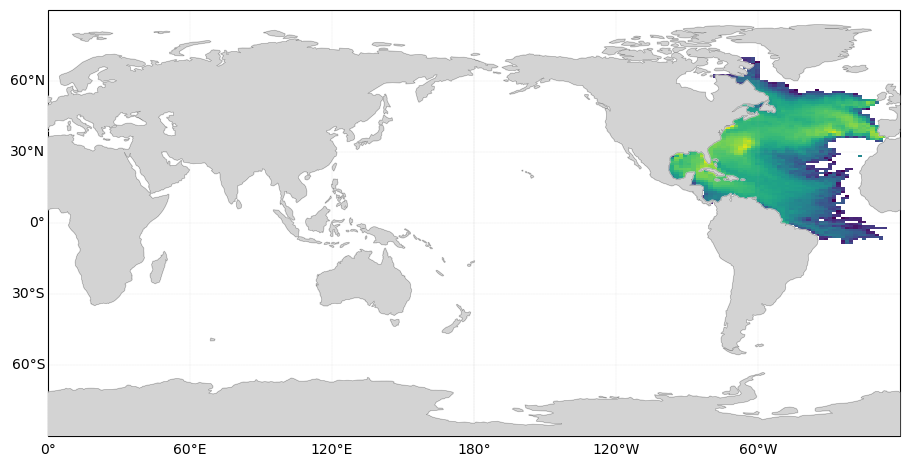

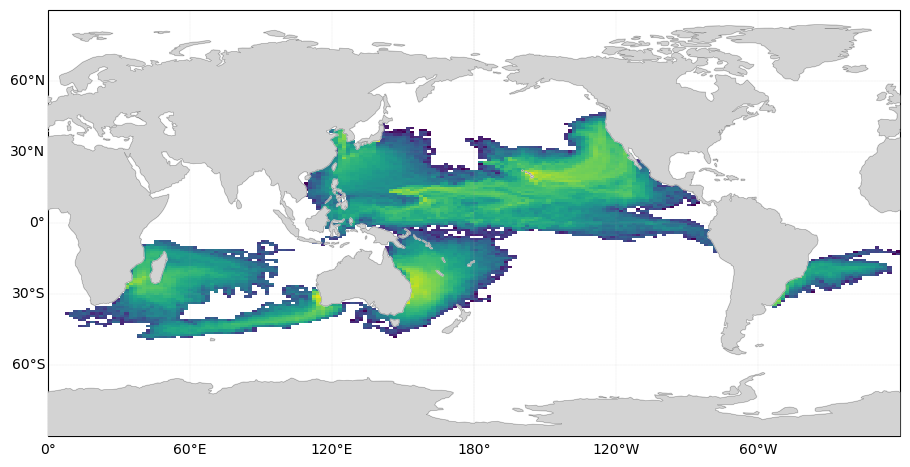

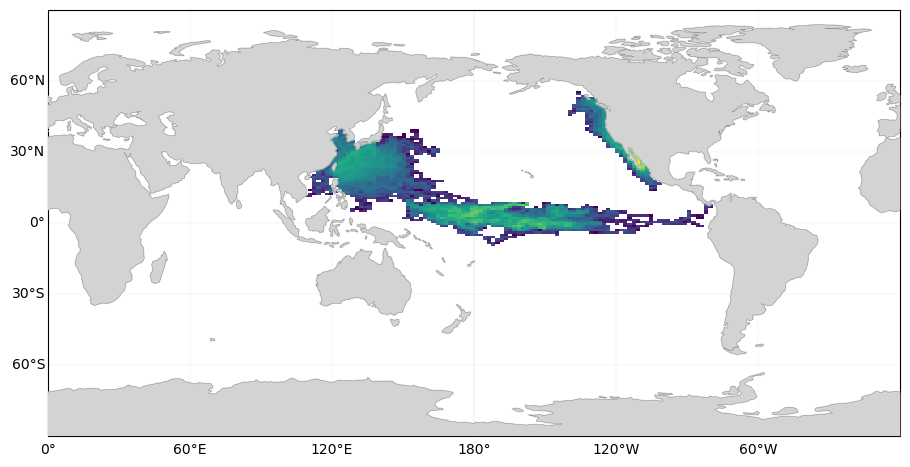

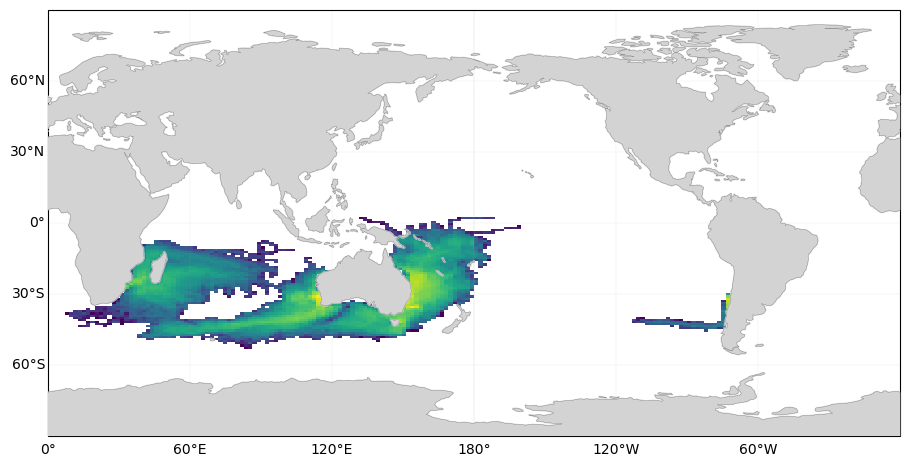

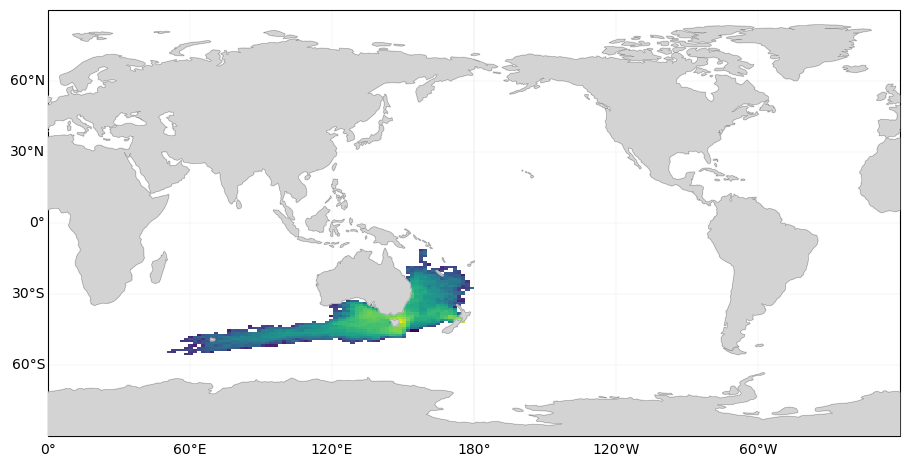

In [14]:
hA = get_histo("A")
hB1 = get_histo("B1")
hB2 = get_histo("B2")
hC1 = get_histo("C1")
hC2 = get_histo("C2")

/home/z3529592/miniforge3/envs/tashdrift/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:1646: UserWarning: Log scale: values of z <= 0 have been masked
  result = super().contourf(*args, **kwargs)
/home/z3529592/miniforge3/envs/tashdrift/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:1646: UserWarning: linewidths is ignored by contourf
  result = super().contourf(*args, **kwargs)
/home/z3529592/miniforge3/envs/tashdrift/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:1646: UserWarning: Log scale: values of z <= 0 have been masked
  result = super().contourf(*args, **kwargs)
/home/z3529592/miniforge3/envs/tashdrift/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:1646: UserWarning: linewidths is ignored by contourf
  result = super().contourf(*args, **kwargs)
/home/z3529592/miniforge3/envs/tashdrift/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:1646: UserWarning: Log scale: values of z <= 0 have been masked
  result = super().contourf(*args, **kwargs)
/home/z35295

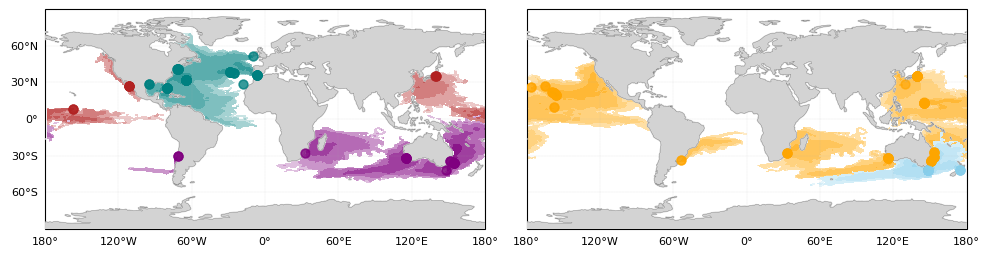

In [17]:
fig, axs = plt.subplots(nrows=1, ncols=2, subplot_kw={'projection': ccrs.PlateCarree()},sharex=True,sharey=True,figsize=(10,6))
yes = 0
for ax in fig.get_axes():
    
    ax.coastlines(resolution='110m',zorder=11,linewidth=.1)
    ax.add_feature(cfeature.LAND,color='lightgrey',zorder=10)
    
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), linestyle='--', zorder=0, linewidth=0.1)
    gl.top_labels = False
    gl.right_labels = False
    if yes == 0:
        gl.left_labels=True
        yes=1
    else:
        gl.left_labels=False

    
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}
    gl.xlocator = mticker.MaxNLocator(6)
    gl.ylocator = mticker.MaxNLocator(6)

# === First subplot
for h, color in zip([hA, hB2, hC1], ['teal', 'firebrick', 'purple']):
    cmap = cmap_seq(['w', color], plot=False)
    axs[0].set_xlim(-180, 180)
    axs[0].set_ylim(-90, 90)
    axs[0].contourf(
        h[1][1:], h[2][1:], h[0].T,
        levels=10,
        norm=mcolors.LogNorm(),
        cmap=cmap,
        linewidths=2,
        transform=ccrs.PlateCarree(),
        alpha=1
    )
    
    for i in range(len(lon_ori)):
        if c_ori[i] == "A":
            color = 'teal'
        elif c_ori[i] == "B2":
            color='firebrick'
        elif c_ori[i] == 'C1':
            color='purple'
        else:
            continue
        axs[0].scatter(lon_ori[i],lat_ori[i],c=color,zorder=12,alpha=.4,s=40)

# === Second subplot
for h, color in zip([hB1, hC2], ['orange', 'skyblue']):
    cmap = cmap_seq(['w', color], plot=False)
    axs[1].set_xlim(-180, 180)
    axs[1].set_ylim(-90, 90)
    axs[1].contourf(
        h[1][1:], h[2][1:], h[0].T,
        levels=10,
        norm=mcolors.LogNorm(),
        cmap=cmap,
        linewidths=2,
        transform=ccrs.PlateCarree(),
        alpha=1
    )
    
    for i in range(len(lon_ori)):
        if c_ori[i] == "B1":
            color='orange'
        elif c_ori[i] == "C2":
            color = "skyblue"
        else:
            continue
        axs[1].scatter(lon_ori[i],lat_ori[i],c=color,zorder=12,alpha=.4,s=40)

fig.tight_layout()
fig.savefig(path_fig + 'contour_density_species_FINAL_1000TRAJFIXED.png', dpi=500, facecolor='w', bbox_inches='tight')


In [19]:
def get_dist(lon,lat):
    distances = np.nan*np.zeros_like(lon)
    
    for i in range(len(lon)):
        distances[i] = haversine(lon[0], lat[0], lon[i], lat[i])
    
    return distances.T


def get_nans(lon):
    matrix = ~np.isnan(lon)
    zeros = np.zeros(matrix.shape)
    zeros[matrix] = 1
    percentage = np.nanmean(zeros,axis=0)
    return percentage

In [20]:
def get_distance_all(mylin):
    distances_lin = []
    nans_lin = []
    print(mylin)
    for i in range(len(files_gaby)):
    
        lin = lineage['lineage'].values[samples_gaby[i]-1]
        if lin == mylin:
            lonA, latA = get_lonlat(xr.open_dataset(files_gaby[i]))
            distances_lin.append(get_dist(lonA,latA))
            nans_lin.append(get_nans(lonA))
            
    for i in range(len(files_gaby_right)):
        lin = lineage['lineage'].values[samples_gaby_right[i]-1]
        if lin == mylin:
            lonR, latR = get_lonlat_hand(xr.open_dataset(files_gaby_right[i]))
            distances_lin.append(get_dist(lonR,latR))
            nans_lin.append(get_nans(lonR))

    
    for i in range(len(files_gaby_left)):
        lin = lineage['lineage'].values[samples_gaby_left[i]-1]
        if lin == mylin:    
            lonL, latL = get_lonlat_hand(xr.open_dataset(files_gaby_left[i]))
            distances_lin.append(get_dist(lonL,latL))
            nans_lin.append(get_nans(lonL))

    return np.concatenate(distances_lin, axis=1), nans_lin

In [13]:

def plot_trajs(mylin,ax):
    for i in range(len(files_gaby)):
    
        lin = lineage['lineage'].values[samples_gaby[i]-1]
        if lin == mylin:
            lonA, latA = get_lonlat(xr.open_dataset(files_gaby[i]))
            for lo,la in zip(lonA,latA):
                ax.plot(lo,la,alpha=.1,lw=.1)
    for i in range(len(files_gaby_right)):
        lin = lineage['lineage'].values[samples_gaby_right[i]-1]
        if lin == mylin:
            lonR, latR = get_lonlat(xr.open_dataset(files_gaby_right[i]))
            for lo,la in zip(lonR,latR):
                ax.plot(lo,la,alpha=.1,lw=.1)

    
    for i in range(len(files_gaby_left)):
        lin = lineage['lineage'].values[samples_gaby_left[i]-1]
        if lin == mylin:    
            lonL, latL = get_lonlat(xr.open_dataset(files_gaby_left[i]))
            for lo,la in zip(lonL,latL):
                ax.plot(lo,la,alpha=.1,lw=.1)

    return ax

In [21]:
a_all, nans_a = get_distance_all("A")
b1_all, nans_b1 = get_distance_all("B1")
b2_all, nans_b2 = get_distance_all("B2")
c1_all, nans_c1 = get_distance_all("C1")
c2_all, nans_c2 = get_distance_all("C2")


A
B1
B2
C1
C2


/home/z3529592/miniforge3/envs/tashdrift/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:1646: UserWarning: Log scale: values of z <= 0 have been masked
  result = super().contourf(*args, **kwargs)
/home/z3529592/miniforge3/envs/tashdrift/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:1646: UserWarning: linewidths is ignored by contourf
  result = super().contourf(*args, **kwargs)
/home/z3529592/miniforge3/envs/tashdrift/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:1646: UserWarning: Log scale: values of z <= 0 have been masked
  result = super().contourf(*args, **kwargs)
/home/z3529592/miniforge3/envs/tashdrift/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:1646: UserWarning: linewidths is ignored by contourf
  result = super().contourf(*args, **kwargs)
/home/z3529592/miniforge3/envs/tashdrift/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:1646: UserWarning: Log scale: values of z <= 0 have been masked
  result = super().contourf(*args, **kwargs)
/home/z35295

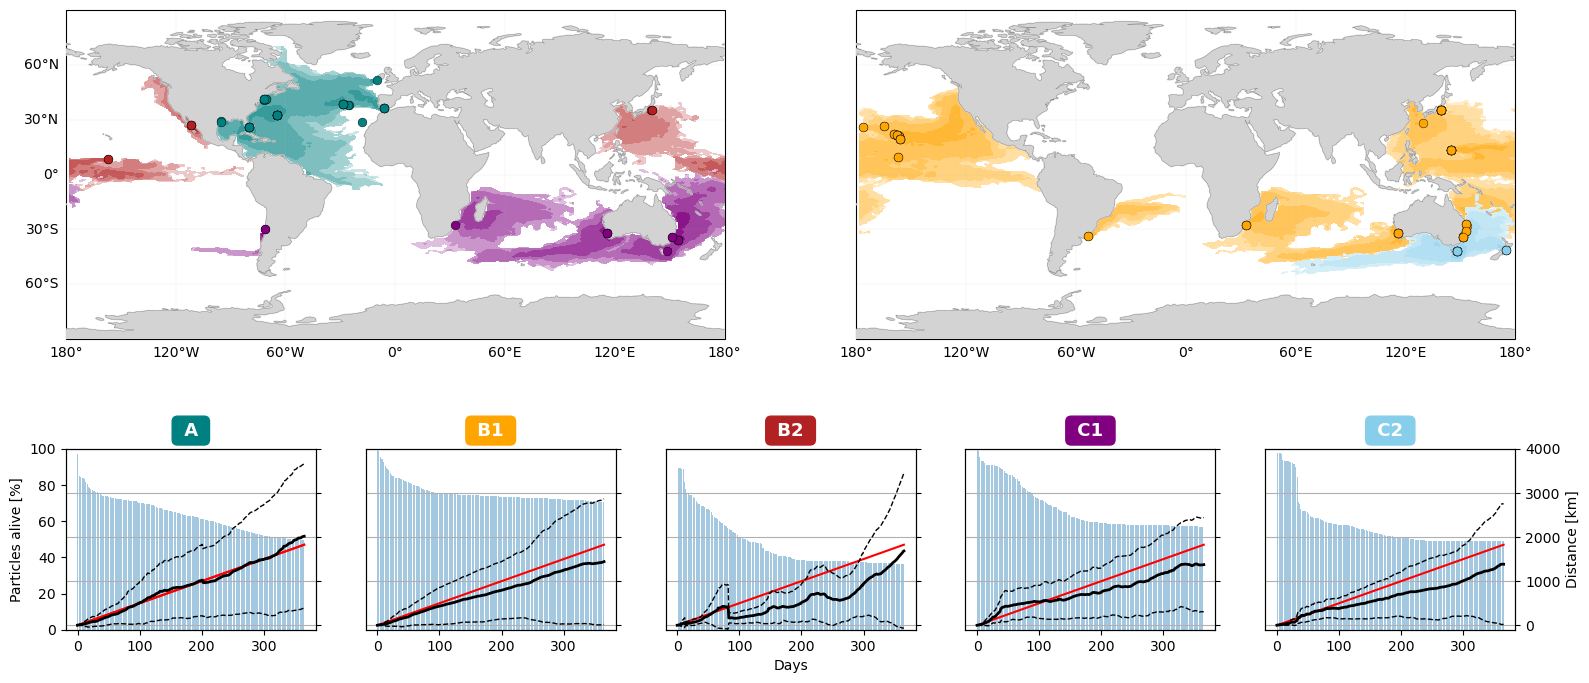

In [37]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

fig = plt.figure(figsize=(16, 8))

# === Outer layout: 2 rows
outer_gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1], figure=fig)

# === Top maps: 2 equal subplots
gs_top = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer_gs[0])
axs_maps = [fig.add_subplot(gs_top[0, i], projection=ccrs.PlateCarree()) for i in range(2)]

# === Bottom line/bar plots: 5 subplots
gs_bottom = gridspec.GridSpecFromSubplotSpec(1, 5, subplot_spec=outer_gs[1])
axs_line = [fig.add_subplot(gs_bottom[0, i]) for i in range(5)]

# === Map settings
yes = 0
for ax in axs_maps:
    ax.coastlines(resolution='110m', zorder=11, linewidth=.1)
    ax.add_feature(cfeature.LAND, color='lightgrey', zorder=10)
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), linestyle='--', zorder=0, linewidth=0.1)
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = yes == 0
    yes = 1
    gl.xlocator = mticker.MaxNLocator(6)
    gl.ylocator = mticker.MaxNLocator(6)
    ax.set_xlim(-180, 180)
    ax.set_ylim(-90, 90)

# === First map
for h, color in zip([hA, hB2, hC1], ['teal', 'firebrick', 'purple']):
    cmap = cmap_seq(['w', color], plot=False)
    axs_maps[0].contourf(h[1][1:], h[2][1:], h[0].T, levels=10, norm=mcolors.LogNorm(),
                         cmap=cmap, linewidths=2, transform=ccrs.PlateCarree(), alpha=1)

for i in range(len(lon_ori)):
    if c_ori[i] == "A":
        color = 'teal'
    elif c_ori[i] == "B2":
        color = 'firebrick'
    elif c_ori[i] == "C1":
        color = 'purple'
    else:
        continue
    axs_maps[0].scatter(lon_ori[i], lat_ori[i], c=color, edgecolors='k', linewidths=.3, zorder=12, alpha=1, s=40)

# === Second map
for h, color in zip([hB1, hC2], ['orange', 'skyblue']):
    cmap = cmap_seq(['w', color], plot=False)
    axs_maps[1].contourf(h[1][1:], h[2][1:], h[0].T, levels=10, norm=mcolors.LogNorm(),
                         cmap=cmap, linewidths=2, transform=ccrs.PlateCarree(), alpha=1)

for i in range(len(lon_ori)):
    if c_ori[i] == "B1":
        color = 'orange'
    elif c_ori[i] == "C2":
        color = "skyblue"
    else:
        continue
    axs_maps[1].scatter(lon_ori[i], lat_ori[i], c=color, zorder=12, alpha=1, s=40, edgecolors='k', linewidths=.3)

# === Line and bar plots
for ax, value, nans, title in zip(
    axs_line, [a_all, b1_all, b2_all, c1_all, c2_all],
    [nans_a, nans_b1, nans_b2, nans_c1, nans_c2],
    ['A', 'B1', 'B2', 'C1', 'C2']
):
    ax2 = ax.twinx()
    x = np.arange(0, 366)
    if ax is not axs_line[-1]:
        ax2.set_yticklabels([])
    else:
        ax2.set_ylabel('Distance [km]')

    if title == 'A':
        ax2.plot(x, 5 * x, c='r', label='5 km/day', zorder=5)
    ax2.plot(x, 5 * x, c='r', zorder=5)
    ax2.plot(x, np.nanmean(value / 1e3, axis=1), c='k', lw=2, zorder=7)
    ax2.plot(x, np.nanmean(value / 1e3, axis=1) - np.nanstd(value / 1e3, axis=1), c='k', lw=1, ls='--', zorder=7)
    ax2.plot(x, np.nanmean(value / 1e3, axis=1) + np.nanstd(value / 1e3, axis=1), c='k', lw=1, ls='--', zorder=7)

    ax.bar(x, 100 * np.nanmean(nans, axis=0), alpha=0.4)
    ax.set_ylim(0, 100)
    ax2.set_ylim(-100, 4000)

    ax2.yaxis.grid(zorder=0)


# === Label boxes (once, on top of each lower subplot)
label_colors = ['skyblue', 'purple', 'firebrick', 'orange', 'teal'][::-1]
label_names = [' A ', ' B1 ', ' B2 ', ' C1 ', ' C2 ']
for a, label, color in zip(axs_line, label_names, label_colors):
    a.text(0.5, 1.1, label, transform=a.transAxes, rotation=0,
           fontsize=13, fontweight='bold', color='white', va='center', ha='center',
           bbox=dict(boxstyle='round,pad=0.3', facecolor=color, edgecolor=color, alpha=1))

# === Labels
axs_line[0].set_ylabel('Particles alive [%]')
axs_line[2].set_xlabel('Days')

for a in axs_line[1:]:
    a.set_yticks([])

fig.tight_layout(h_pad=2)
fig.savefig(path_fig + 'contour_and_beaching_combined_FINAL_1000TRAJFIXED.png', dpi=500, facecolor='w', bbox_inches='tight')
